#import libraries and data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pickle

df = pd.read_csv("train_with_lags_2.csv")   # your cleaned dataset
df = df.sort_values("date_id")         # important for time-series modeling

# split up training and validation sets

In [ ]:
TARGET = "forward_returns"

feature_cols = [c for c in df.columns
                if c not in ["date_id", TARGET, "risk_free_rate", "market_forward_excess_returns"]]

# LGBM traning

In [ ]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df[TARGET]

# Splitting the data into training and validation sets. Adjust test_size as needed.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False) # shuffle=False is important for time-series data

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (7216, 114)
y_train shape: (7216,)
X_val shape: (1805, 114)
y_val shape: (1805,)


In [ ]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
val_data   = lgb.Dataset(X_val,   label=y_val)


model = lgb.LGBMRegressor(
 objective="huber",
    alpha=0.9,
    boosting_type="gbdt",

    # Tree shape
    num_leaves=25,
    max_depth=5,

    # Regularization
    min_data_in_leaf=80,
    lambda_l2=1.0,

    # Sampling
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,

    # Learning
    learning_rate=0.02,
    n_estimators=4000
)

In [ ]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=10000000000000000),
        lgb.log_evaluation(period=100)  # prints every 100 rounds
    ]
)

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ign

LGBMRegressor(alpha=0.9, bagging_fraction=0.8, bagging_freq=5,
              feature_fraction=0.8, lambda_l2=1.0, learning_rate=0.02,
              max_depth=5, min_data_in_leaf=80, n_estimators=4000,
              num_leaves=25, objective='huber')

# feature importance

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np # Import numpy for sqrt function

preds_val = model.predict(X_val)
mse = mean_squared_error(y_val, preds_val) # Calculate MSE
rmse = np.sqrt(mse) # Take the square root to get RMSE
print("Validation RMSE:", rmse)

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
Validation RMSE: 0.011098418272156131


# save model

In [ ]:
model.booster_.save_model("lgbm_model.txt")
print("Model saved to lgbm_model.txt")

with open("lgbm_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Saved model to lgbm_model.pkl")

Model saved to lgbm_model.txt
Saved model to lgbm_model.pkl


#accuracy check

In [ ]:
# Load ground-truth data from the test set
df_test = pd.read_csv("test_with_lags.csv")

# Prepare features (X_test) from the test data
X_test = df_test[feature_cols]

# Make predictions using the trained model
preds_test = model.predict(X_test)

# Add predictions to the test dataframe for analysis
df_test["prediction"] = preds_test

print("Predictions made on test_with_lags.csv and added to df_test.")
print("Note: The 'forward_returns' column (TARGET) is not present in test_with_lags.csv, so accuracy metrics cannot be computed directly.")

# For example, to print the first few predictions:
# print(df_test[['date_id', 'prediction']].head())

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
Predictions made on test_with_lags.csv and added to df_test.
Note: The 'forward_returns' column (TARGET) is not present in test_with_lags.csv, so accuracy metrics cannot be computed directly.


#accuracy metrics & directional accuracy

In [ ]:
true = y_val
pred = preds_val

mae = np.mean(np.abs(true - pred))
rmse = np.sqrt(np.mean((true - pred) ** 2))
corr = np.corrcoef(true, pred)[0,1]
r2   = r2_score(true, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)
print("r^2:", r2)

# MAE 0.009 means model predictions are off by 9% daily on average
# RMSE 0.12 is low enough, and close enough to MAE
#
#

MAE: 0.007906709227199963
RMSE: 0.011098418272156131
Correlation: -0.039055419324955085
r^2: -0.0006078928492561086


In [ ]:
direction_accuracy = (np.sign(true) == np.sign(pred)).mean()
print("Directional Accuracy:", direction_accuracy)

# directional accuracy of 0.55 supposedly very good according to chatGPT

Directional Accuracy: 0.5529085872576177


# plot for visual assistance

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
RMSE: 0.011098
MAE:  0.007907
R² :  -0.000608
Approx. Prediction Sharpe: -3.9898


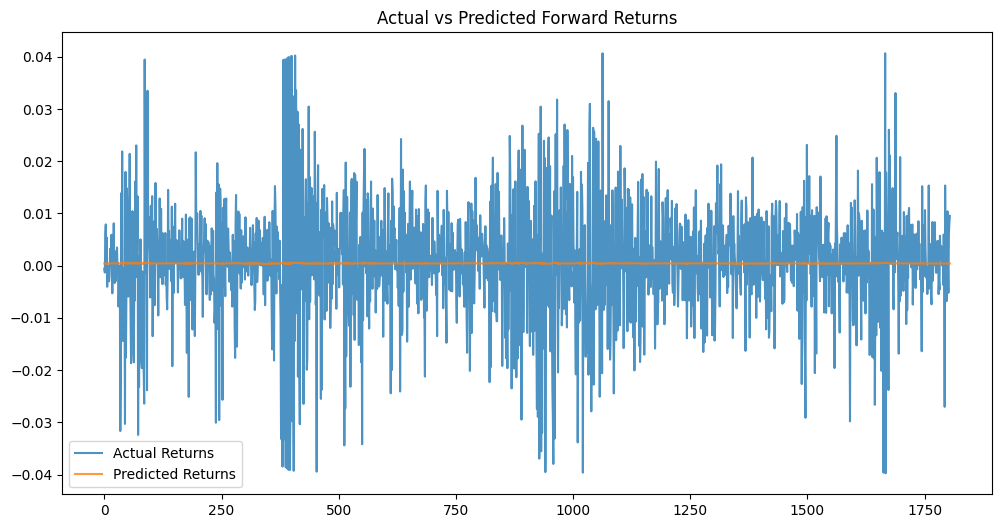

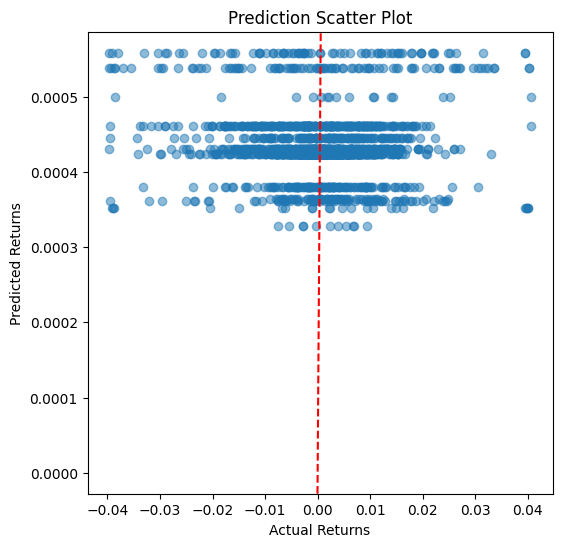

In [ ]:
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R² :  {r2:.6f}")

excess_returns = y_pred - y_val.mean()
sharpe = np.mean(excess_returns) / np.std(excess_returns)
print(f"Approx. Prediction Sharpe: {sharpe:.4f}")

plt.figure(figsize=(12,6))
plt.plot(y_val.values, label="Actual Returns", alpha=0.8)
plt.plot(y_pred, label="Predicted Returns", alpha=0.8)
plt.title("Actual vs Predicted Forward Returns")
plt.legend()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Prediction Scatter Plot")
plt.axline((0,0), slope=1, color='red', linestyle='--')
plt.show()

# sharpe ratio

In [ ]:
pred_dir = np.sign(preds_val)
strategy_return = pred_dir * y_val

sharpe = (strategy_return.mean() / strategy_return.std()) * np.sqrt(252)
print("Strategy Sharpe Ratio:", sharpe)

Strategy Sharpe Ratio: 0.8841045785020052


#cumulative returns

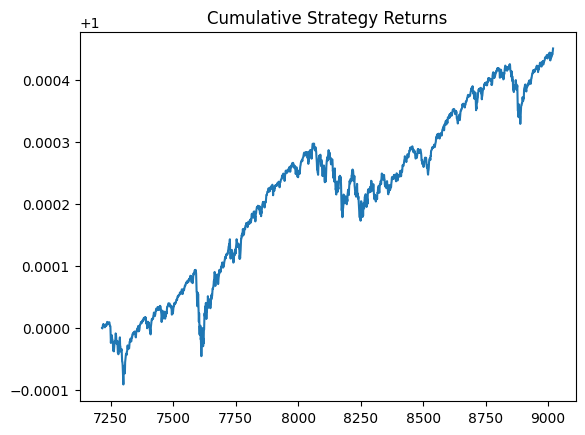

In [ ]:
strategy_returns = preds_val * y_val
cum_returns = (1 + strategy_returns).cumprod()

plt.plot(cum_returns)
plt.title("Cumulative Strategy Returns")
plt.show()

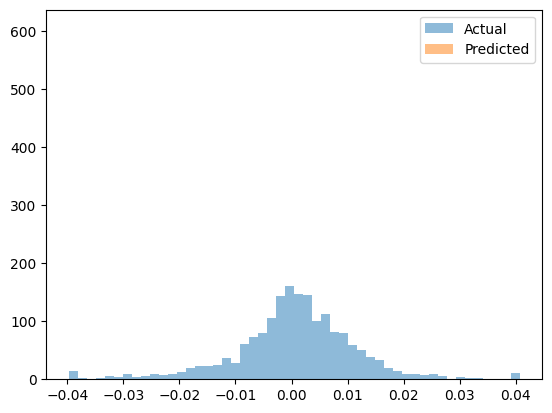

In [ ]:
plt.hist(y_val, bins=50, alpha=0.5, label='Actual')
plt.hist(preds_val, bins=50, alpha=0.5, label='Predicted')
plt.legend()
plt.show()